<a href="https://colab.research.google.com/github/Annsjana123/Credit-Card-Fraud-Detection-Using-AIML/blob/main/CreditCardFraudDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **INSTALL LIBRARIES**

In [ ]:
!pip install imbalanced-learn
!pip install xgboost
!pip install shap

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

import joblib

import warnings
warnings.filterwarnings("ignore")

# **MOUNT GOOGLE DRIVE**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path="/content/drive/MyDrive/creditcard.csv"

df=pd.read_csv(path)

In [ ]:
df.head()

df.tail()

df.shape

df.columns

df.dtypes

,0
Time,float64
V1,float64
V2,float64
V3,float64
V4,float64
V5,float64
V6,float64
V7,float64
V8,float64
V9,float64


# **DATA UNDERSTANDING**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
print(df.shape)

(284807, 31)


In [ ]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
df.duplicated().sum()

np.int64(1081)

In [ ]:
df.nunique()

,0
Time,124592
V1,275663
V2,275663
V3,275663
V4,275663
V5,275663
V6,275663
V7,275663
V8,275663
V9,275663


In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


In [ ]:
df['Class'].value_counts(normalize=True)*100

,proportion
Class,
0,99.827251
1,0.172749


In [ ]:
df=df.drop_duplicates()

In [ ]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 283726 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    283726 non-null  float64
 1   V1      283726 non-null  float64
 2   V2      283726 non-null  float64
 3   V3      283726 non-null  float64
 4   V4      283726 non-null  float64
 5   V5      283726 non-null  float64
 6   V6      283726 non-null  float64
 7   V7      283726 non-null  float64
 8   V8      283726 non-null  float64
 9   V9      283726 non-null  float64
 10  V10     283726 non-null  float64
 11  V11     283726 non-null  float64
 12  V12     283726 non-null  float64
 13  V13     283726 non-null  float64
 14  V14     283726 non-null  float64
 15  V15     283726 non-null  float64
 16  V16     283726 non-null  float64
 17  V17     283726 non-null  float64
 18  V18     283726 non-null  float64
 19  V19     283726 non-null  float64
 20  V20     283726 non-null  float64
 21  V21     283726 

# **EXPLORATORY DATA ANALYSIS**

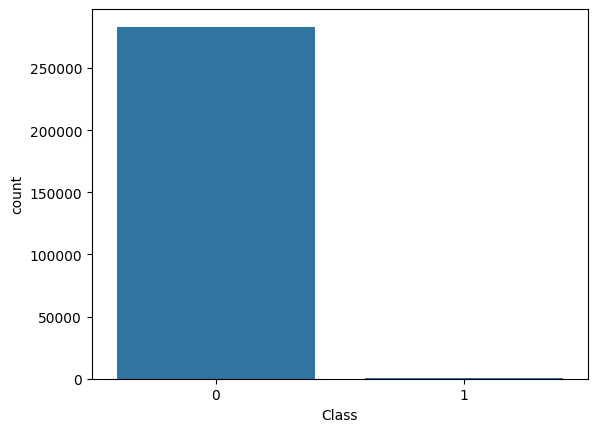

In [ ]:
sns.countplot(x='Class',data=df)
plt.show()

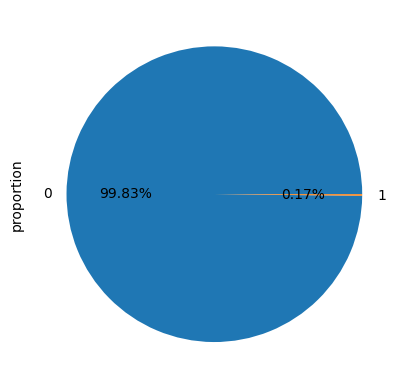

In [ ]:
df['Class'].value_counts(normalize=True).plot(kind='pie',autopct="%1.2f%%")
plt.show()

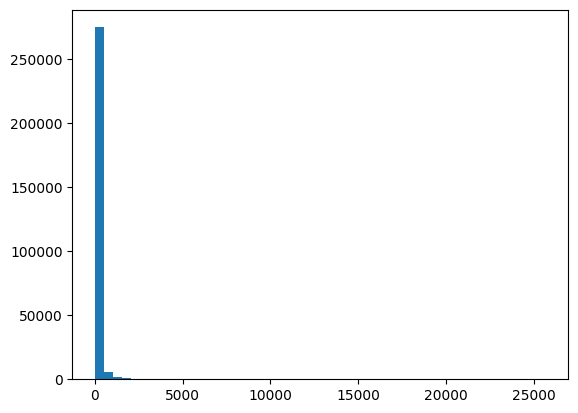

In [ ]:
plt.hist(df['Amount'],bins=50)
plt.show()

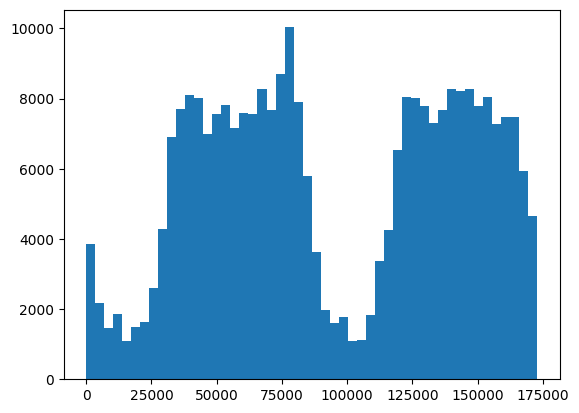

In [ ]:
plt.hist(df['Time'],bins=50)
plt.show()

<Axes: ylabel='Amount'>

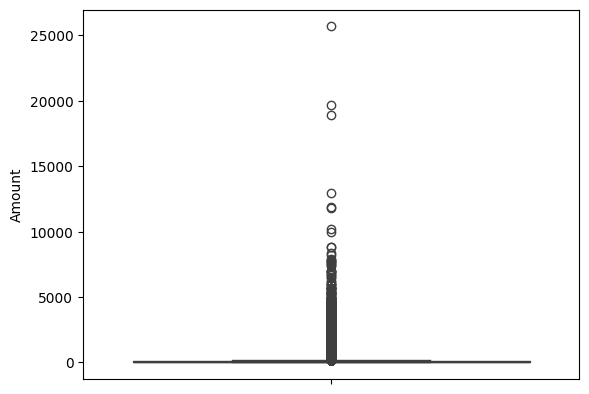

In [ ]:
sns.boxplot(df['Amount'])

<Axes: xlabel='Amount', ylabel='Density'>

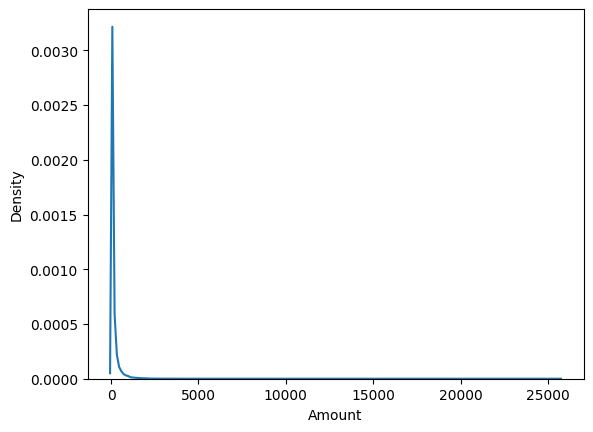

In [ ]:
sns.kdeplot(df['Amount'])

In [ ]:
corr=df.corr()

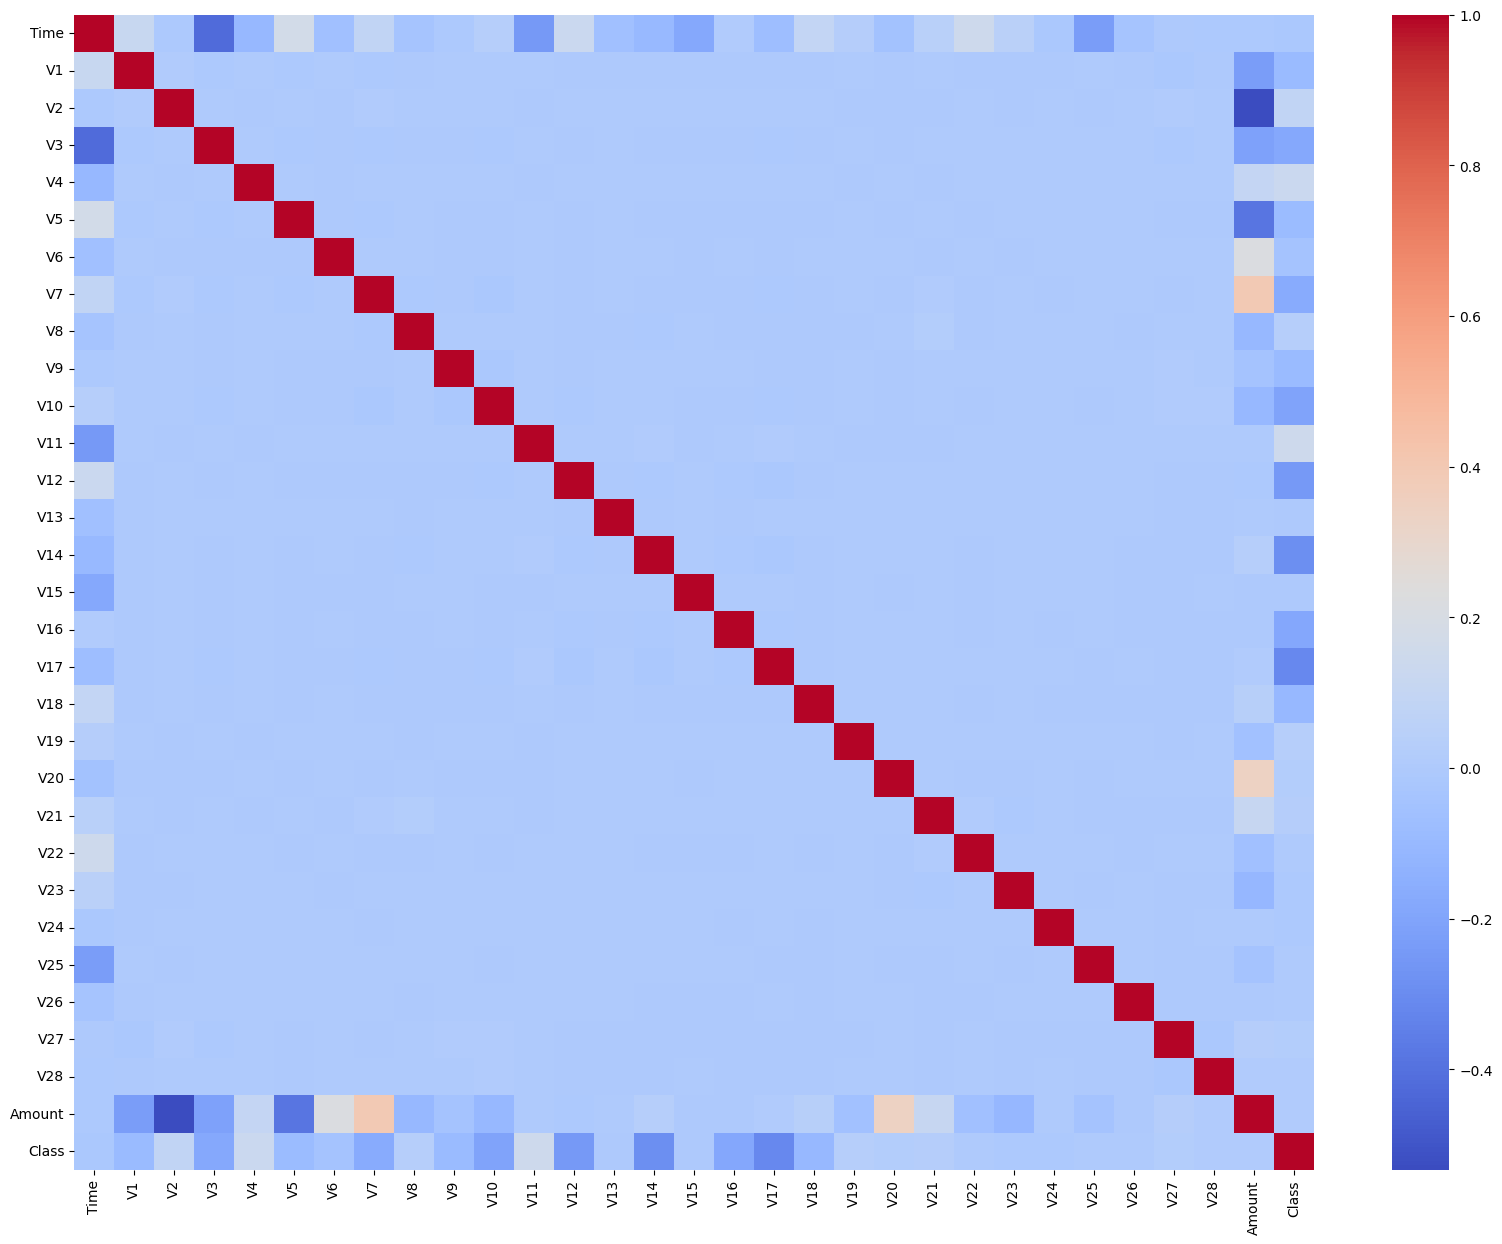

In [ ]:
plt.figure(figsize=(20,15))
sns.heatmap(corr,cmap="coolwarm")
plt.show()

<Axes: xlabel='Class', ylabel='Amount'>

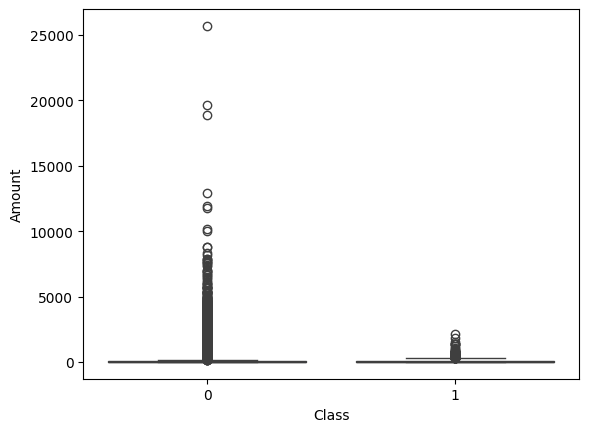

In [ ]:
sns.boxplot(x='Class',y='Amount',data=df)

<Axes: xlabel='Class', ylabel='Time'>

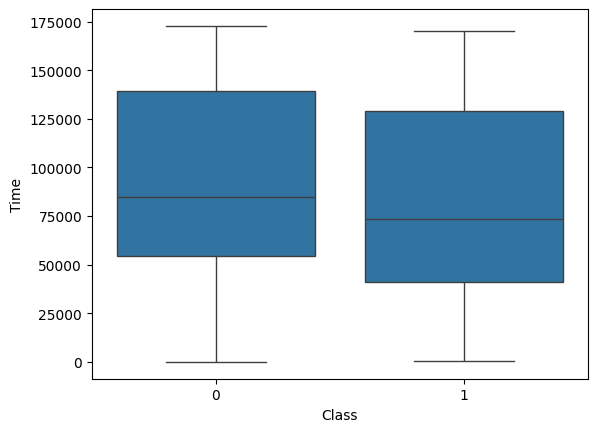

In [ ]:
sns.boxplot(x='Class',y='Time',data=df)

# **FEATURE ENGINEERING**

In [ ]:
X=df.drop("Class",axis=1)

y=df["Class"]

In [ ]:
scaler=StandardScaler()

X_scaled=scaler.fit_transform(X)

In [ ]:
robust=RobustScaler()

X_robust=robust.fit_transform(X)

In [ ]:
smote=SMOTE(random_state=42)

X_smote,y_smote=smote.fit_resample(X_scaled,y)

In [ ]:
rus=RandomUnderSampler(random_state=42)

X_under,y_under=rus.fit_resample(X_scaled,y)

# **TRAIN TEST SPLIT**

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(
X_smote,
y_smote,
test_size=0.2,
random_state=42
)

# **MODELS**

In [ ]:
lr=LogisticRegression()

lr.fit(X_train,y_train)

pred=lr.predict(X_test)

In [ ]:
accuracy_score(y_test,pred)

precision_score(y_test,pred)

recall_score(y_test,pred)

f1_score(y_test,pred)

roc_auc_score(y_test,pred)

np.float64(0.946349903411365)

In [ ]:
import time
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

start = time.time()

dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train, y_train)

end = time.time()

pred = dt.predict(X_test)

print("Training Time:", round(end - start, 2), "seconds")
print("Accuracy :", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred))
print("Recall   :", recall_score(y_test, pred))
print("F1 Score :", f1_score(y_test, pred))
print("ROC-AUC  :", roc_auc_score(y_test, pred))

Training Time: 47.07 seconds
Accuracy : 0.9855077580272192
Precision: 0.9885814435179776
Recall   : 0.9824592269392495
F1 Score : 0.9855108271711699
ROC-AUC  : 0.985517908459264


In [ ]:
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

start = time.time()

rf = RandomForestClassifier(
    n_estimators=20,
    max_depth=10,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

end = time.time()

pred = rf.predict(X_test)

print("Training Time:", round(end - start, 2), "seconds")
print("Accuracy :", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred))
print("Recall   :", recall_score(y_test, pred))
print("F1 Score :", f1_score(y_test, pred))
print("ROC-AUC  :", roc_auc_score(y_test, pred))

Training Time: 92.46 seconds
Accuracy : 0.9878113360752678
Precision: 0.9982928407130535
Recall   : 0.9773746899136156
F1 Score : 0.987723025771867
ROC-AUC  : 0.987846086079313


In [ ]:
import time
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

start = time.time()

xgb = XGBClassifier(
    n_estimators=20,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

end = time.time()

pred = xgb.predict(X_test)

print("Training Time:", round(end-start,2), "seconds")
print("Accuracy :", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred))
print("Recall   :", recall_score(y_test, pred))
print("F1 Score :", f1_score(y_test, pred))
print("ROC-AUC  :", roc_auc_score(y_test, pred))

Training Time: 3.47 seconds
Accuracy : 0.9703623943090148
Precision: 0.9884198798151564
Recall   : 0.9520751596615
F1 Score : 0.9699071584758218
ROC-AUC  : 0.9704232837430465


# **MODEL COMPARISON**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "XGBoost": xgb
}

results = []

for name, model in models.items():
    pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, pred)
    })

comparison = pd.DataFrame(results)

print(comparison)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.946259   0.972497  0.918859  0.944917  0.946350
1        Decision Tree  0.985508   0.988581  0.982459  0.985511  0.985518
2        Random Forest  0.987811   0.998293  0.977375  0.987723  0.987846
3              XGBoost  0.970362   0.988420  0.952075  0.969907  0.970423


In [ ]:
comparison = pd.DataFrame(results)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.946259,0.972497,0.918859,0.944917,0.946350
1,Decision Tree,0.985508,0.988581,0.982459,0.985511,0.985518
2,Random Forest,0.987811,0.998293,0.977375,0.987723,0.987846
3,XGBoost,0.970362,0.988420,0.952075,0.969907,0.970423


In [ ]:
comparison.sort_values(by="F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Random Forest,0.987811,0.998293,0.977375,0.987723,0.987846
1,Decision Tree,0.985508,0.988581,0.982459,0.985511,0.985518
3,XGBoost,0.970362,0.988420,0.952075,0.969907,0.970423
0,Logistic Regression,0.946259,0.972497,0.918859,0.944917,0.946350


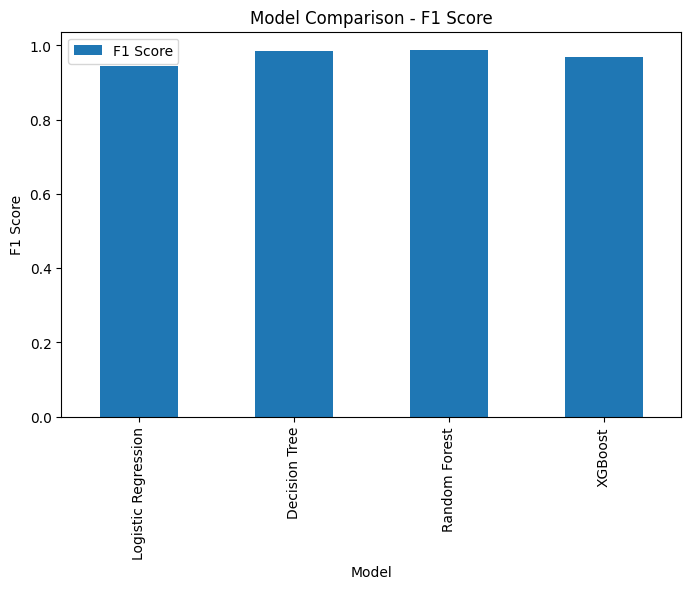

In [ ]:
import matplotlib.pyplot as plt

comparison.plot(
    x="Model",
    y="F1 Score",
    kind="bar",
    figsize=(8,5)
)

plt.title("Model Comparison - F1 Score")
plt.ylabel("F1 Score")
plt.show()

# **EVALUATION**

<Axes: >

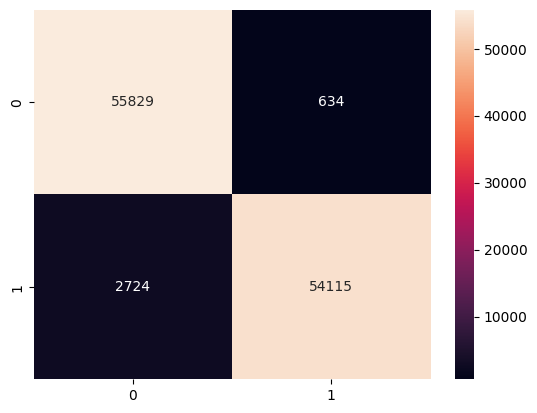

In [ ]:
cm=confusion_matrix(y_test,pred)

sns.heatmap(cm,annot=True,fmt="d")

In [ ]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97     56463
           1       0.99      0.95      0.97     56839

    accuracy                           0.97    113302
   macro avg       0.97      0.97      0.97    113302
weighted avg       0.97      0.97      0.97    113302



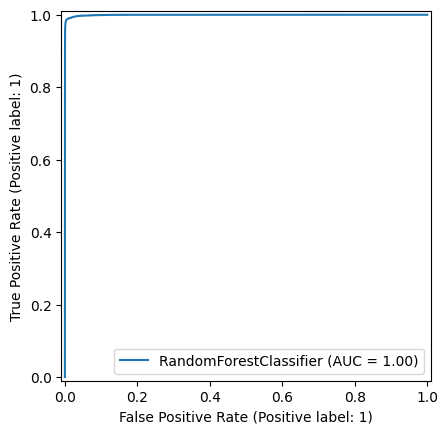

In [ ]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(rf,X_test,y_test)

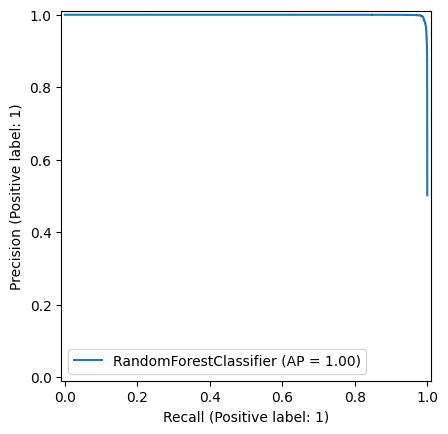

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_estimator(rf,X_test,y_test)

# **SHAP**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop("Class", axis=1)
y = df["Class"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

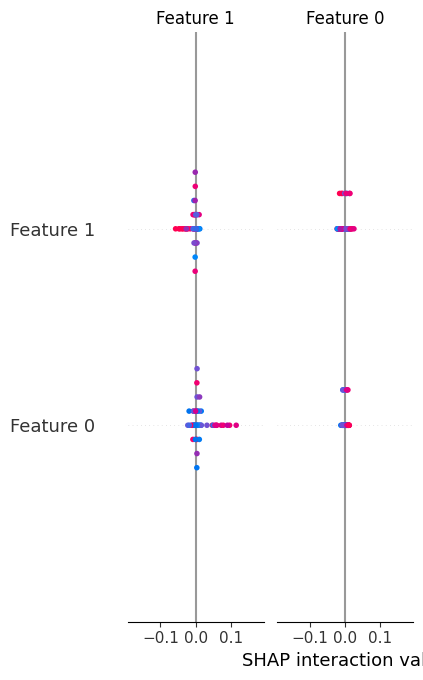

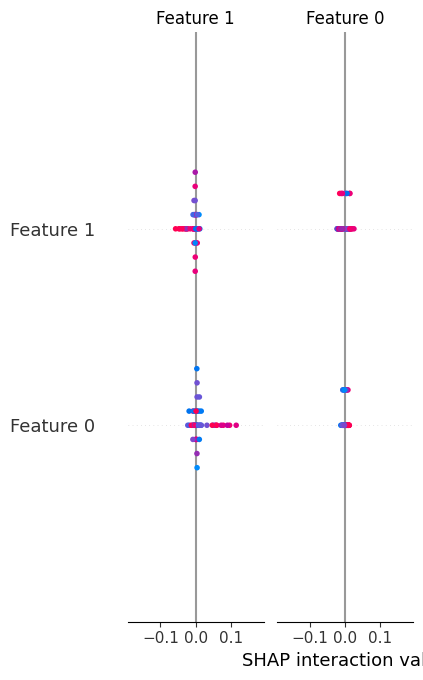

In [ ]:
import shap
import matplotlib.pyplot as plt

# Use only a small sample for faster execution
X_sample = X_test[:50]

# Create SHAP explainer
explainer = shap.TreeExplainer(rf)

# Calculate SHAP values
shap_values = explainer.shap_values(X_sample)

# SHAP Summary Plot
shap.summary_plot(shap_values, X_sample)

# SHAP Feature Importance Plot
shap.summary_plot(shap_values, X_sample, plot_type="bar")

# **SAVE MODEL**

In [ ]:
joblib.dump(rf,"fraud_model.pkl")

joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

# **PREDICTION FUNCTION**

In [ ]:
import joblib
import numpy as np

# Load saved model and scaler
model = joblib.load("fraud_model.pkl")
scaler = joblib.load("scaler.pkl")

def predict_transaction(transaction):
    transaction = np.array(transaction).reshape(1, -1)
    transaction = scaler.transform(transaction)

    prediction = model.predict(transaction)[0]
    probability = model.predict_proba(transaction)[0][1]

    if prediction == 1:
        print("Prediction: Fraud Transaction")
    else:
        print("Prediction: Genuine Transaction")

    print("Fraud Probability:", round(probability * 100, 2), "%")

# Example: Use the first transaction from your dataset
sample = df.drop("Class", axis=1).iloc[0].values
predict_transaction(sample)

Prediction: Genuine Transaction
Fraud Probability: 5.03 %


# **IMAGES**

## Fraud vs Genuine Distribution

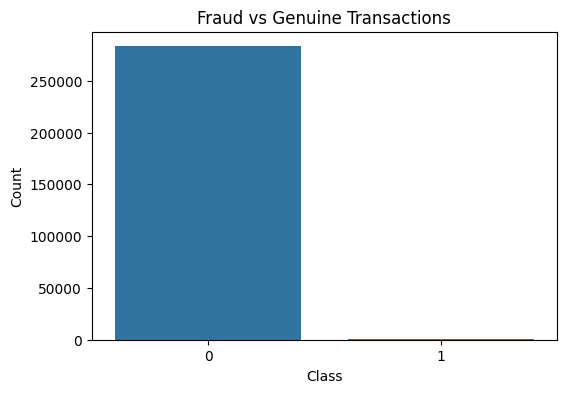

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Genuine Transactions")
plt.xlabel("Class")
plt.ylabel("Count")
plt.savefig("fraud_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## Correlation Heatmap

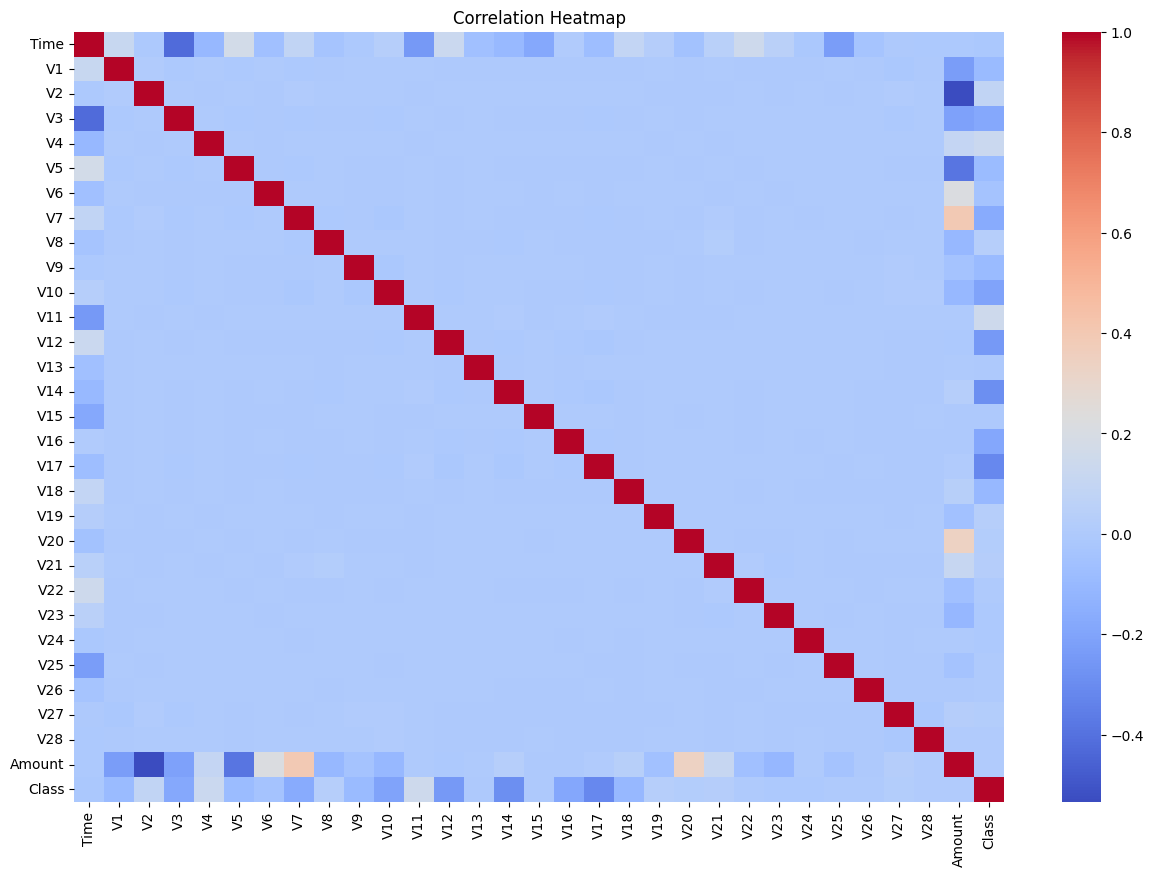

In [ ]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.savefig("heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## Transaction Amount Distribution

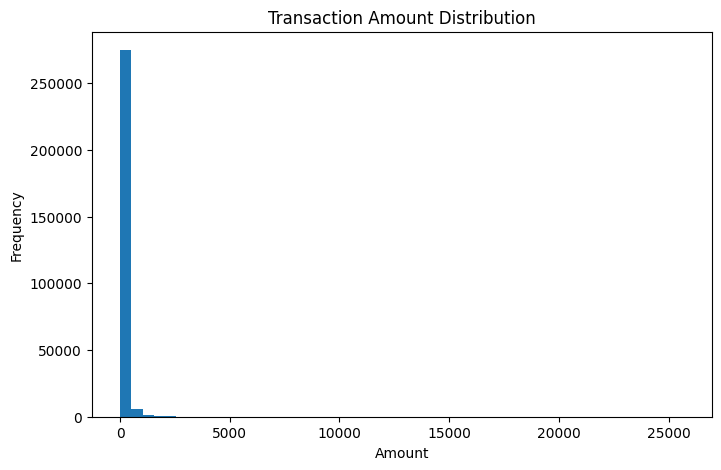

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df["Amount"], bins=50)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.savefig("amount_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## Transaction Time Distribution

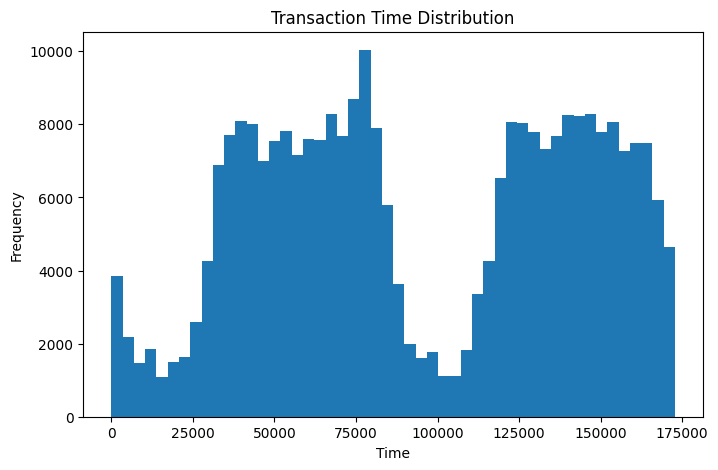

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df["Time"], bins=50)
plt.title("Transaction Time Distribution")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.savefig("time_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## Confusion Matrix (Best Model)

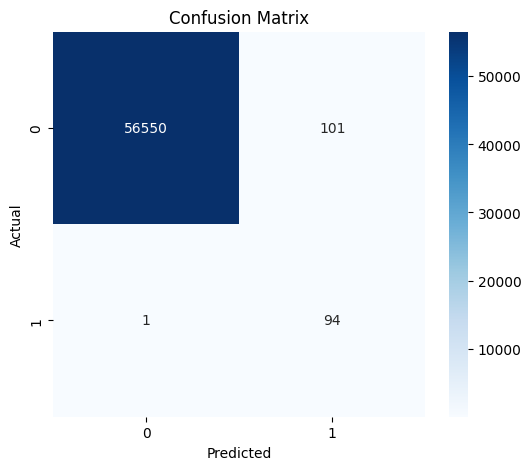

In [ ]:
from sklearn.metrics import confusion_matrix

pred = rf.predict(X_test)

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

## ROC Curve

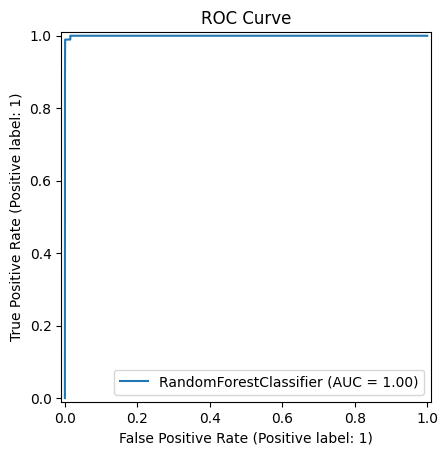

In [ ]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(rf, X_test, y_test)

plt.title("ROC Curve")
plt.savefig("roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

## Precision-Recall Curve

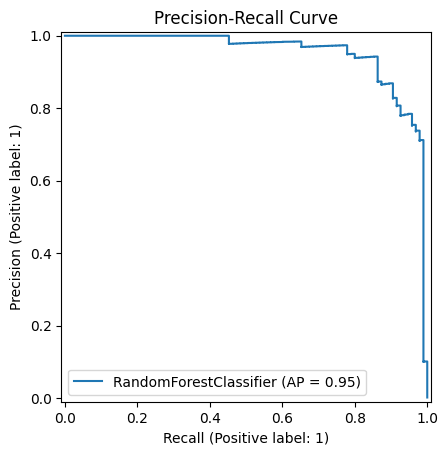

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_estimator(rf, X_test, y_test)

plt.title("Precision-Recall Curve")
plt.savefig("precision_recall_curve.png", dpi=300, bbox_inches="tight")
plt.show()

## Feature Importance (Random Forest)

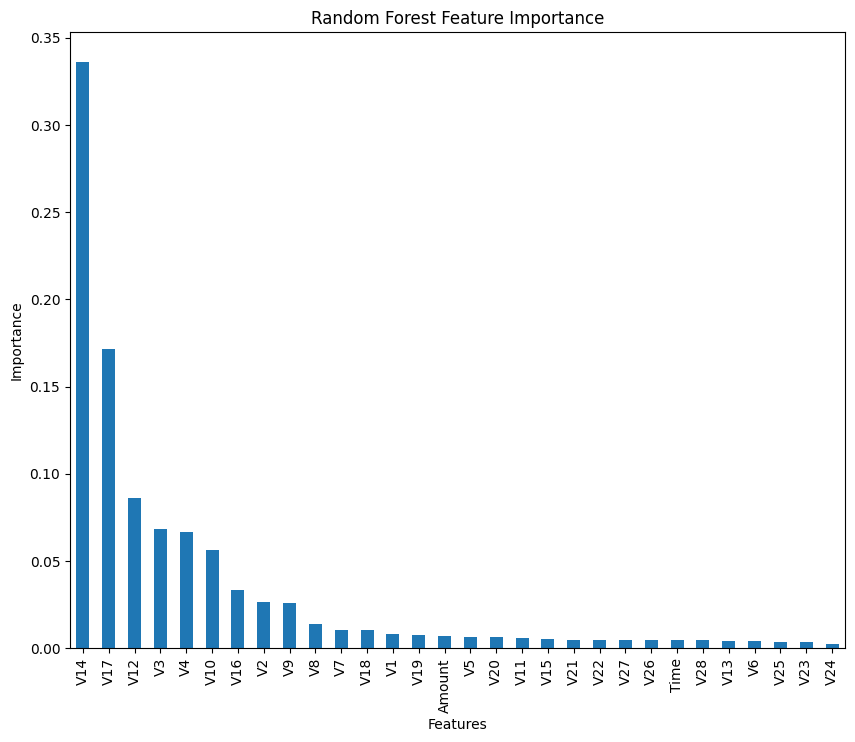

In [ ]:
import pandas as pd

importance = pd.Series(
    rf.feature_importances_,
    index=df.drop("Class", axis=1).columns
).sort_values(ascending=False)

plt.figure(figsize=(10,8))
importance.plot(kind="bar")
plt.title("Random Forest Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

## SHAP Feature Importance

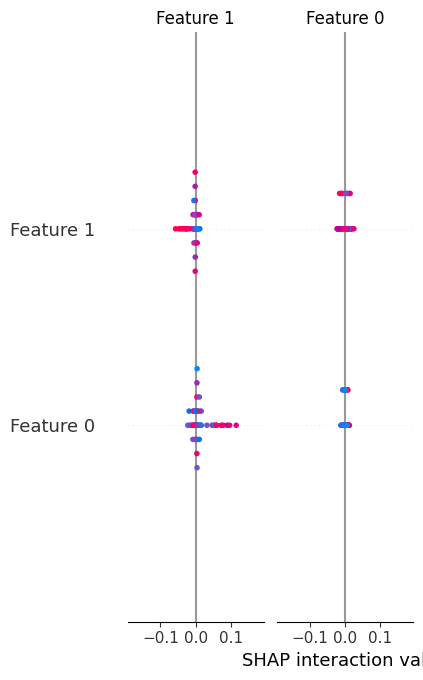

In [ ]:
import shap

X_sample = X_test[:50]

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample, show=False)

plt.savefig("shap_summary.png", dpi=300, bbox_inches="tight")

plt.show()

## SHAP Bar Plot

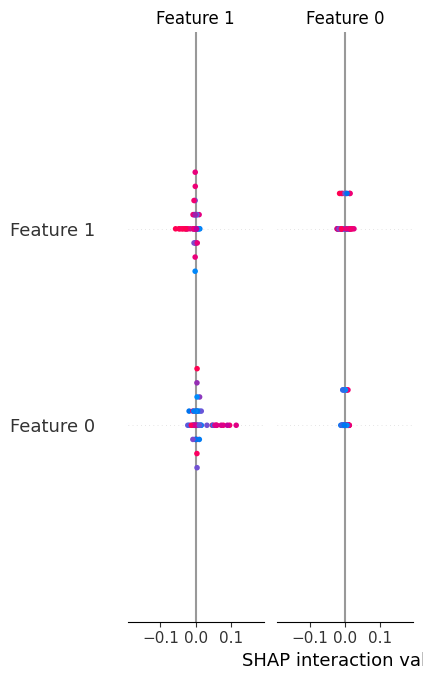

In [ ]:
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)

plt.savefig("shap_bar.png", dpi=300, bbox_inches="tight")

plt.show()